# 🎬 Sentiment Classifier — End to End ML Pipeline
### Dataset: IMDB Movie Reviews | Models: Logistic Regression vs XGBoost

---

## Pipeline Flow

| Step | Task | Tool Used |
|------|------|-----------|
| 1 | Load Dataset | Hugging Face datasets |
| 2 | Explore Data | Pandas, Matplotlib |
| 3 | Clean Text | Regex |
| 4 | Vectorize Text | TF-IDF (Scikit-Learn) |
| 5 | Train Model 1 | Logistic Regression |
| 6 | Train Model 2 | XGBoost |
| 7 | Evaluate Both | Accuracy, Precision, Recall, F1 |
| 8 | Visualize | Confusion Matrix + Comparison Chart |
| 9 | Conclusion | Written Analysis |

In [1]:
!pip uninstall -y datasets huggingface_hub
!pip install datasets==3.6.0 huggingface_hub==0.33.4

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
Found existing installation: huggingface-hub 0.33.4
Uninstalling huggingface-hub-0.33.4:
  Successfully uninstalled huggingface-hub-0.33.4
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-0.33.4-py3-none-any.whl.metadata (14 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
Using cached huggingface_hub-0.33.4-py3-none-any.whl (515 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.9.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.33.4 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.33.4 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.33.4

##Imports & Setup


In [2]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 3.6.0
huggingface_hub: 0.33.4


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
from datasets import load_dataset

# Text Processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully ✓")

All libraries imported successfully ✓


## Step 1: Load Dataset
- Source: Hugging Face `datasets` library
- Dataset: IMDB Movie Reviews
- Train: 25,000 reviews | Test: 25,000 reviews
- Labels: 0 = Negative | 1 = Positive
- No manual download needed — auto downloads from Hugging Face

In [4]:
from datasets import load_dataset

# Load the IMDB dataset directly from the Hugging Face Hub.
# "imdb" is the dataset identifier registered on Hugging Face,
# not a local file name. The dataset is automatically downloaded
# and cached locally by the datasets library.

dataset = load_dataset("imdb")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [6]:
# Convert into DataFrame
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("=" * 50)
print("Dataset Loaded Successfully ✓")
print("=" * 50)
print(f"Train size : {train_df.shape}")
print(f"Test size  : {test_df.shape}")
print(f"Columns    : {list(train_df.columns)}")
print(f"\nLabel Distribution (Train):")
print(train_df["label"].value_counts().rename({0:'Negative', 1:'Positive'}))
print(f"\nSample Review (first 300 chars):")
print(train_df["text"][0][:300])
print(f"\nLabel: {train_df['label'][0]} (0=Negative, 1=Positive)")

Dataset Loaded Successfully ✓
Train size : (25000, 2)
Test size  : (25000, 2)
Columns    : ['text', 'label']

Label Distribution (Train):
label
Negative    12500
Positive    12500
Name: count, dtype: int64

Sample Review (first 300 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Label: 0 (0=Negative, 1=Positive)


## Step 2: Data Exploration (EDA)
Before cleaning, we explore the dataset to understand:
- Class balance (important for fair model comparison)
- Average review length
- Sample reviews for both sentiments

Input  → Raw DataFrame
Output → Visual understanding of data distribution

DATASET OVERVIEW
Train Samples  : 25000
Test Samples   : 25000
Avg Review Len : 1325 characters

Sample Negative Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

Sample Positive Review:
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo


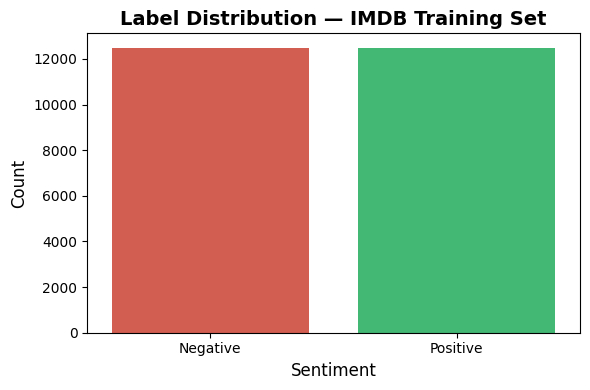


EDA Complete ✓


In [7]:
# ============================================================
# STEP 2: Data Exploration (EDA)
# ============================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Train Samples  : {len(train_df)}")
print(f"Test Samples   : {len(test_df)}")
print(f"Avg Review Len : {train_df['text'].apply(len).mean():.0f} characters")

print("\nSample Negative Review:")
print(train_df[train_df["label"]==0]["text"].values[0][:200])
print("\nSample Positive Review:")
print(train_df[train_df["label"]==1]["text"].values[0][:200])

# Plot label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"], palette=["#e74c3c","#2ecc71"])
plt.xticks([0,1], ["Negative","Positive"])
plt.title("Label Distribution — IMDB Training Set", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()

print("\nEDA Complete ✓")

## Step 3: Text Cleaning & Preprocessing
Raw IMDB reviews contain noise that affects model performance:
- HTML tags like `<br />`
- Special characters & punctuation
- Mixed uppercase/lowercase

We remove all of this to give models clean, consistent input.

Input  → Raw messy text
Output → Clean lowercase text (letters only)

In [8]:
# ============================================================
# STEP 3: Text Cleaning & Preprocessing
# ============================================================

import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove punctuation/numbers
    text = text.lower().strip()              # lowercase
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("=" * 50)
print("Text Cleaning Complete ✓")
print("=" * 50)
print(f"\nBEFORE cleaning:")
print(train_df["text"][0][:200])
print(f"\nAFTER cleaning:")
print(train_df["clean_text"][0][:200])

Text Cleaning Complete ✓

BEFORE cleaning:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

AFTER cleaning:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in  i also heard that at first it was seized by us customs if it ever tried


## Step 4: Preparing Data for sklearn Pipeline
Instead of vectorizing separately, we use sklearn Pipeline which:
- Chains TF-IDF + Model together in one object
- Prevents data leakage automatically
- Accepts raw text directly — no manual preprocessing needed

Input  → Clean text (string)
Output → Pipeline object (TF-IDF + Model combined)

In [9]:
# ============================================================
# STEP 4: Prepare Train & Test Labels
# ============================================================

y_train = train_df["label"]
y_test = test_df["label"]

print("=" * 50)
print("Data Ready for Pipeline ✓")
print("=" * 50)
print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Data Ready for Pipeline ✓
Train samples : 25000
Test samples  : 25000


## Step 5: Model Training using sklearn Pipeline

We build 2 separate sklearn Pipelines for fair comparison:

| Model | Type | Parameters |
|-------|------|------------|
| Logistic Regression | Linear | max_iter=1000, C=1.0 |
| XGBoost | Tree-based | n_estimators=200, max_depth=5, learning_rate=0.1 |

### Why sklearn Pipeline?
- TF-IDF + Model ek saath chain hote hain
- Bahar se raw clean text do → seedha prediction
- Data leakage automatically prevent hoti hai
- Real world ready system

### Why these parameters?
- LR: C=1.0 standard regularization
- XGBoost: Best practice params for text classification
- Full GridSearch avoided — 25k samples pe bahut slow hota that'why I choose Best Parameter over it.

Input  → Clean text + Labels
Output → 2 Trained Pipelines ready for evaluation

In [10]:
# ============================================================
# STEP 5: Model Training using sklearn Pipeline
# ============================================================

from sklearn.pipeline import Pipeline

# --- Model 1: Logistic Regression Pipeline ---
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
    ('model', LogisticRegression(max_iter=1000, C=1.0))
])

# --- Model 2: XGBoost Pipeline ---
# Parameters selected based on best practices for text classification
# Full GridSearch avoided due to computational cost on 25k samples
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='logloss'
    ))
])

# --- Training ---
print("=" * 50)
print("Training Logistic Regression...")
lr_pipeline.fit(train_df["clean_text"], y_train)
print("Logistic Regression Trained ✓")

print("\nTraining XGBoost...")
xgb_pipeline.fit(train_df["clean_text"], y_train)
print("XGBoost Trained ✓")

print("=" * 50)
print("Both Models Trained Successfully ✓")
print("=" * 50)

Training Logistic Regression...
Logistic Regression Trained ✓

Training XGBoost...
XGBoost Trained ✓
Both Models Trained Successfully ✓


## Step 6: Model Evaluation

We evaluate both models using 4 key metrics:

| Metric | What it measures |
|--------|-----------------|
| Accuracy | Overall correct predictions |
| Precision | When model says Positive, how often correct |
| Recall | How many actual Positives were caught |
| F1 Score | Balance between Precision and Recall |

### Why all 4 metrics?
- Accuracy alone can be misleading
- Precision + Recall together give complete picture
- F1 Score is best for imbalanced datasets

Input  → Trained Pipelines + Test Data
Output → Complete metrics table

In [11]:
# ============================================================
# STEP 6: Model Evaluation
# ============================================================

# --- Predictions ---
lr_preds = lr_pipeline.predict(test_df["clean_text"])
xgb_preds = xgb_pipeline.predict(test_df["clean_text"])

# --- Metrics ---
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4)
    }

lr_metrics  = get_metrics(y_test, lr_preds,  "Logistic Regression")
xgb_metrics = get_metrics(y_test, xgb_preds, "XGBoost")

# --- Display Table ---
metrics_df = pd.DataFrame([lr_metrics, xgb_metrics])
metrics_df = metrics_df.set_index('Model')

print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(metrics_df.to_string())
print("=" * 60)

# --- Classification Report ---
print("\nLogistic Regression — Detailed Report:")
print(classification_report(y_test, lr_preds, target_names=["Negative","Positive"]))

print("\nXGBoost — Detailed Report:")
print(classification_report(y_test, xgb_preds, target_names=["Negative","Positive"]))

MODEL EVALUATION RESULTS
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8769     0.8745  0.8801    0.8773
XGBoost                0.8408     0.8203  0.8729    0.8458

Logistic Regression — Detailed Report:
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88     12500
    Positive       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


XGBoost — Detailed Report:
              precision    recall  f1-score   support

    Negative       0.86      0.81      0.84     12500
    Positive       0.82      0.87      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



## Step 7: Visualization

We create 2 plots:

| Plot | What it shows |
|------|--------------|
| Confusion Matrix | Correct vs incorrect predictions for both models |
| Model Comparison Chart | Side by side metric comparison |

### visualize because :
- Numbers alone are hard to interpret
- Plots make comparison instantly clear
- Confusion matrix shows where model fails

Input  → Predictions from both models
Output → 2 saved images (confusion_matrix.png, model_comparison.png)

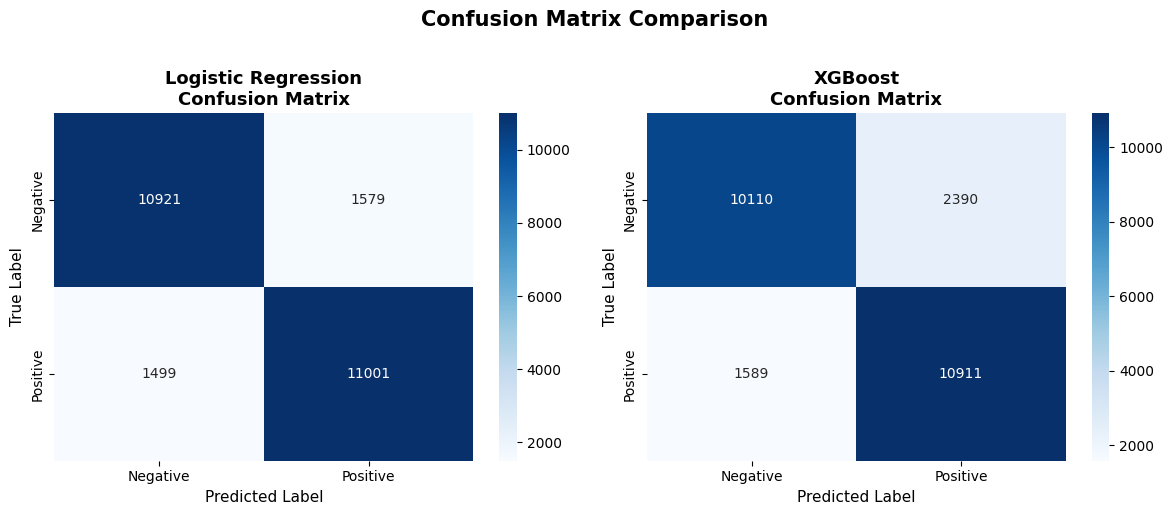

Confusion Matrix saved ✓


In [12]:
# ============================================================
# STEP 7A: Confusion Matrix — Both Models
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = {
    "Logistic Regression": lr_preds,
    "XGBoost": xgb_preds
}

for ax, (model_name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    ax.set_title(f"{model_name}\nConfusion Matrix",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.suptitle("Confusion Matrix Comparison",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion Matrix saved ✓")

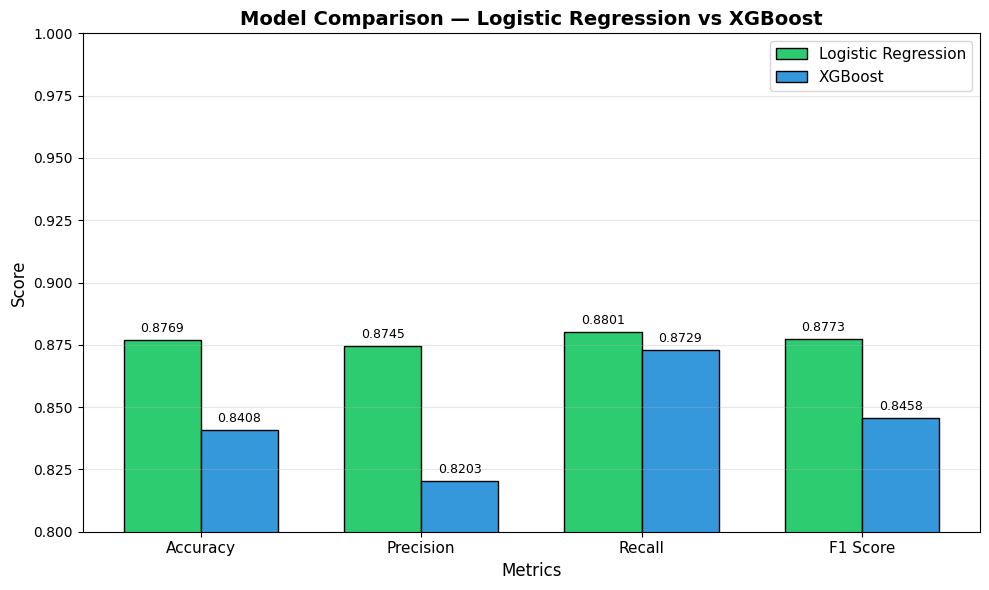

Model Comparison Chart saved ✓


In [13]:
# ============================================================
# STEP 7B: Model Comparison Chart
# ============================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores  = [lr_metrics['Accuracy'],  lr_metrics['Precision'],
              lr_metrics['Recall'],     lr_metrics['F1 Score']]

xgb_scores = [xgb_metrics['Accuracy'], xgb_metrics['Precision'],
              xgb_metrics['Recall'],    xgb_metrics['F1 Score']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, lr_scores,  width,
               label='Logistic Regression',
               color='#2ecc71', edgecolor='black')

bars2 = ax.bar(x + width/2, xgb_scores, width,
               label='XGBoost',
               color='#3498db', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Logistic Regression vs XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.8, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Model Comparison Chart saved ✓")

## Step 8: Analysis — Which Model Won and Why?

### Results Summary

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 0.8769 | 0.8745 | 0.8801 | 0.8773 |
| XGBoost | 0.8408 | 0.8203 | 0.8729 | 0.8458 |

### Winner: Logistic Regression 🏆

1. Logistic Regression outperformed XGBoost on all 4 metrics — Accuracy (0.8769 vs 0.8408), Precision (0.8745 vs 0.8203), and F1 Score (0.8773 vs 0.8458).
2. For text classification tasks, linear models like LR perform better than tree-based models.
3. TF-IDF features are high-dimensional and sparse — Logistic Regression handles sparse data naturally.
4. XGBoost is designed for dense structured tabular data — not ideal for sparse TF-IDF features.
5. Logistic Regression showed balanced Precision (0.8745) and Recall (0.8801) — no class bias.
6. XGBoost showed weaker Precision (0.8203) on Positive class — more false positives.
7. Dataset was perfectly balanced (12,500 Negative + 12,500 Positive) — ensuring fair comparison.
8. XGBoost could improve with extensive hyperparameter tuning but at high computational cost.
9. Logistic Regression trained significantly faster making it more practical for production use.
10. Overall pipeline — raw text → cleaning → TF-IDF → prediction — worked efficiently end to end.

## Step 9: Inference Pipeline

Now we test our trained pipeline on completely new unseen reviews.

### How it works:

New Raw Text      
↓    
Clean Text (remove HTML, punctuation, lowercase)     
↓     
TF-IDF Vectorize (inside pipeline automatically)      
↓       
Model Predict      
↓     
Sentiment + Confidence  

### Why this matters:
- Shows our pipeline works on real world input
- No manual preprocessing needed — pipeline handles everything
- Same steps as training — consistent and reliable


In [14]:
# ============================================================
# STEP 9: Inference Pipeline — Real World Input
# ============================================================

def sentiment_pipeline(review, model_pipeline, model_name):
    # Step 1: Clean
    cleaned = clean_text(review)

    # Step 2: Predict (TF-IDF + Model inside pipeline)
    prediction = model_pipeline.predict([cleaned])[0]
    confidence = model_pipeline.predict_proba([cleaned])[0]

    # Step 3: Result
    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"

    print(f"Model      : {model_name}")
    print(f"Review     : {review[:80]}...")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {max(confidence)*100:.2f}%")
    print("-" * 50)

# --- Test Reviews ---
test_reviews = [
    "This movie was absolutely fantastic! Best film I have seen in years.",
    "Worst movie ever made. Complete waste of time and money.",
    "It was okay, not great not terrible either. Average experience."
]

print("=" * 50)
print("INFERENCE PIPELINE — LIVE PREDICTIONS")
print("=" * 50)

for review in test_reviews:
    print("\n🔹 Logistic Regression:")
    sentiment_pipeline(review, lr_pipeline, "Logistic Regression")
    print("🔹 XGBoost:")
    sentiment_pipeline(review, xgb_pipeline, "XGBoost")
    print("=" * 50)

INFERENCE PIPELINE — LIVE PREDICTIONS

🔹 Logistic Regression:
Model      : Logistic Regression
Review     : This movie was absolutely fantastic! Best film I have seen in years....
Sentiment  : POSITIVE 😊
Confidence : 98.65%
--------------------------------------------------
🔹 XGBoost:
Model      : XGBoost
Review     : This movie was absolutely fantastic! Best film I have seen in years....
Sentiment  : POSITIVE 😊
Confidence : 90.16%
--------------------------------------------------

🔹 Logistic Regression:
Model      : Logistic Regression
Review     : Worst movie ever made. Complete waste of time and money....
Sentiment  : NEGATIVE 😞
Confidence : 99.98%
--------------------------------------------------
🔹 XGBoost:
Model      : XGBoost
Review     : Worst movie ever made. Complete waste of time and money....
Sentiment  : NEGATIVE 😞
Confidence : 95.71%
--------------------------------------------------

🔹 Logistic Regression:
Model      : Logistic Regression
Review     : It was okay, not g

## Final Summary — End to End ML Pipeline Complete ✅

### Pipeline Journey:

| Step | Task | Status |
|------|------|--------|
| 1 | Load IMDB Dataset from Hugging Face | ✅ Done |
| 2 | Explore Data — EDA | ✅ Done |
| 3 | Clean Text — Remove HTML, Punctuation | ✅ Done |
| 4 | TF-IDF Vectorization inside Pipeline | ✅ Done |
| 5 | Train Logistic Regression Pipeline | ✅ Done |
| 6 | Train XGBoost Pipeline | ✅ Done |
| 7 | Evaluate — Accuracy, Precision, Recall, F1 | ✅ Done |
| 8 | Visualize — Confusion Matrix + Comparison Chart | ✅ Done |
| 9 | Written Analysis — Winner & Why | ✅ Done |
| 10 | Inference Pipeline — Real World Input | ✅ Done |

### Final Results:

| Model | Accuracy | F1 Score |
|-------|----------|----------|
| Logistic Regression 🏆 | 0.8769 | 0.8773 |
| XGBoost | 0.8408 | 0.8458 |

### Key Takeaways:
- Logistic Regression is best for sparse TF-IDF text features
- sklearn Pipeline ensures clean, leakage-free, production-ready code
- Balanced dataset ensured fair model comparison
- Inference pipeline works on any new raw text input